QUESTION 4

Derived tramline width: 42.00 pixels


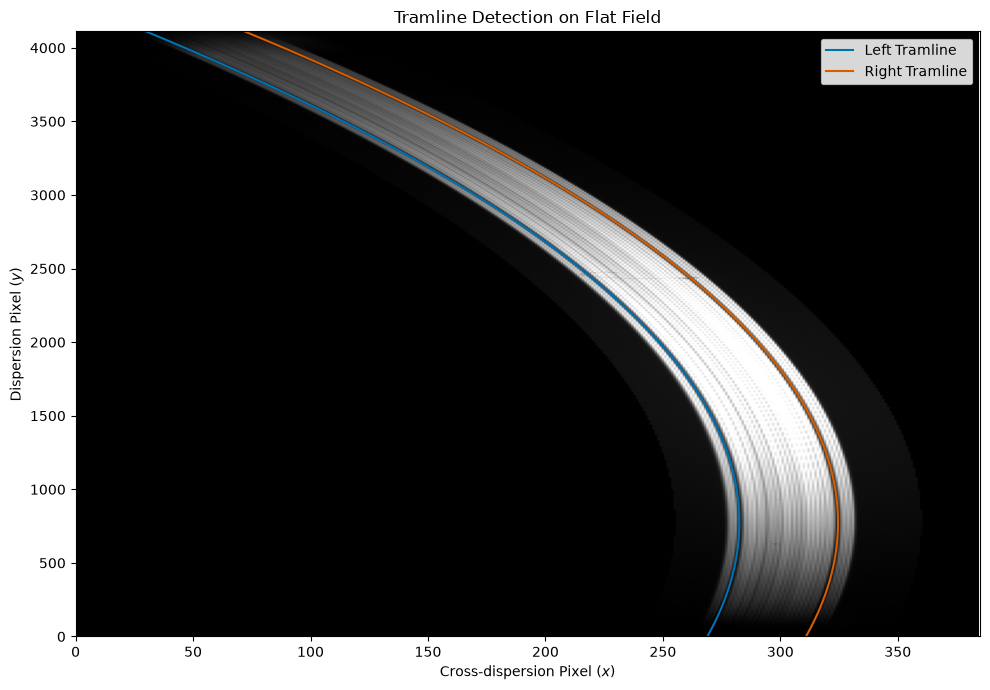

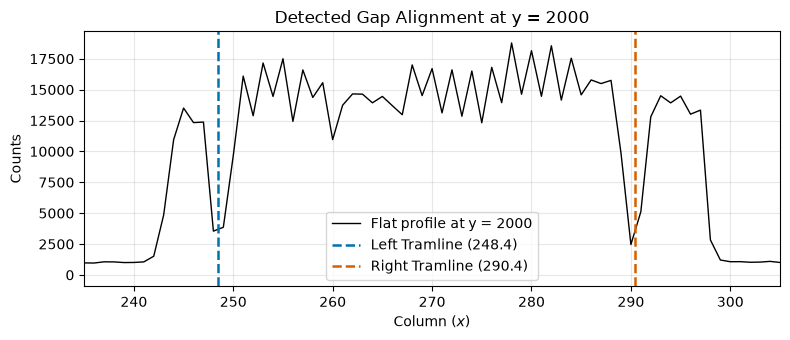

In [38]:
#Part 1 --- Tramlines
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

os.makedirs('figures', exist_ok=True)

#Load data.
with fits.open('data/flat.fits') as hdul:
    flats = np.nan_to_num(hdul[0].data.astype(np.float64))

n_disp, n_xdisp = flats.shape
y_indices = np.arange(n_disp)

#Automated trough detection across rows.
chunk_size = 24 #Tried 16 initially but this works best.
sample_ys = np.arange(chunk_size // 2, n_disp, chunk_size)

left_gaps = []
right_gaps = []
valid_ys = []

for y in sample_ys:
    prof = np.median(flats[max(0, y - chunk_size // 2):min(n_disp, y + chunk_size // 2), :], axis=0)
    
    peak_val = np.max(prof)
    if peak_val < 500:
        continue
    
    peak_x = np.argmax(prof)
    
    #Invert profile so low-illumination troughs become positive peaks.
    #Filter for true dark gaps; flux must drop below 40% (brought this up significantly from initial attempts) 
    #of the peak flux, which naturally rejects the internal inter-fiber teeth.
    trough_candidates, _ = find_peaks(-prof, height=-0.40 * peak_val)
    
    left_candidates = trough_candidates[trough_candidates < peak_x]
    right_candidates = trough_candidates[trough_candidates > peak_x]
    
    if len(left_candidates) > 0 and len(right_candidates) > 0:
        #The bounding gaps are the ones closest to the science bundle.
        t_left = left_candidates[-1]
        t_right = right_candidates[0]
        
        width = t_right - t_left
        #Loose physical filter; bundle span is roughly 35-50 pixels.
        if 30 < width < 55:
            left_gaps.append(t_left)
            right_gaps.append(t_right)
            valid_ys.append(y)

left_gaps = np.array(left_gaps)
right_gaps = np.array(right_gaps)
valid_ys = np.array(valid_ys)

#Calculate constant width and geometric centre directly from the measured gaps.
measured_widths = right_gaps - left_gaps
constant_width = np.median(measured_widths)
measured_centres = 0.5 * (left_gaps + right_gaps)

print(f"Derived tramline width: {constant_width:.2f} pixels")

#Fit smooth 3rd order polynomial to the measured gap midpoints.
poly_coeffs = np.polyfit(valid_ys, measured_centres, deg=3)
fitted_centres = np.polyval(poly_coeffs, y_indices)

left_tramlines = fitted_centres - (constant_width / 2.0)
right_tramlines = fitted_centres + (constant_width / 2.0)

#Plotting
plt.figure(figsize=(10, 7))
plt.imshow(flats, origin='lower', cmap='gray', aspect='auto',
           vmin=np.percentile(flats, 2), vmax=np.percentile(flats, 98))
plt.plot(left_tramlines, y_indices, color='#0072B2', lw=1.5, label='Left Tramline')
plt.plot(right_tramlines, y_indices, color='#D55E00', lw=1.5, label='Right Tramline')
plt.xlim(0, n_xdisp)
plt.ylim(0, n_disp)
plt.title('Tramline Detection on Flat Field')
plt.xlabel('Cross-dispersion Pixel ($x$)')
plt.ylabel('Dispersion Pixel ($y$)')
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='black', framealpha=0.85)
plt.tight_layout()
plt.savefig('figures/tramline_detection.png', dpi=300)
plt.show()

#Check the slice at y = 2000 to confirm placement.
plt.figure(figsize=(8, 3.5))
plt.plot(flats[2000, :], 'k-', lw=1, label='Flat profile at y = 2000')
plt.axvline(left_tramlines[2000], color='#0072B2', lw=1.8, linestyle='--', 
            label=f'Left Tramline ({left_tramlines[2000]:.1f})')
plt.axvline(right_tramlines[2000], color='#D55E00', lw=1.8, linestyle='--', 
            label=f'Right Tramline ({right_tramlines[2000]:.1f})')
plt.xlim(235, 305)
plt.xlabel('Column ($x$)')
plt.ylabel('Counts')
plt.title('Detected Gap Alignment at y = 2000')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Part 1 --- Approach
The tramlines were determined using an automated feature-detection method designed to trace the natural boundaries of the science order directly from the data, avoiding any manual coordinate guessing or hardcoded shifts (which I had to do for a while but really didn't want to rely on). To build a clean picture of the light profile, the 2D flat field is sliced into 24-row median chunks along the dispersion axis. Averaging over these small row blocks smooths away rogue cosmic ray hits, bad pixels, random detector noise etc. all while keeping the true shape of the spectral order intact. Inverting these cross-sections then turns the dark dips into clear peaks that standard detection tools can easily identify. 

Distinguishing the outer edges of the order from the small dips between individual illuminated fibers inside the bundle was quite tricky. Because these internal ripples only drop down to around 60-75% of the bundle's peak brightness, candidate boundaries are filtered by requiring their light levels to fall below 40% of the row maximum. Starting from the brightest central fiber, the method steps outward to grab the nearest qualifying drop on either side --- this cleanly isolates the core science bundle while completely ignoring adjacent calibration channels and stray background light.

Using the midpoints between the two outer edges, a 3rd-order polynomial is fitted against the row coordinates to capture the gentle optical curve the spectrum traces across the detector. Offsetting this smooth center path outward by half the measured width produces the final pair of tramlines, neatly framing the science bundle from the bottom of the array all the way to the top. As a final sanity check, the script also displays a quick cross-section plot showing that the detected boundaries drop squarely into the centre of both bounding dips, visually confirming the accuracy of the trough-finding step (mainly useful for quickly identifying how far off I was in each iteration, so not really worth saving each time).

Dispersion direction: Wavelength decreases with row index y.


* Ca II $\lambda 8662$ $\rightarrow y = 448$ (Rest: $8662.14\,\mathrm{\AA}$)

* Ca II $\lambda 8542$ $\rightarrow y = 2789$ (Rest: $8542.09\,\mathrm{\AA}$)

* Ca II $\lambda 8498$ $\rightarrow y = 3459$ (Rest: $8498.02\,\mathrm{\AA}$)

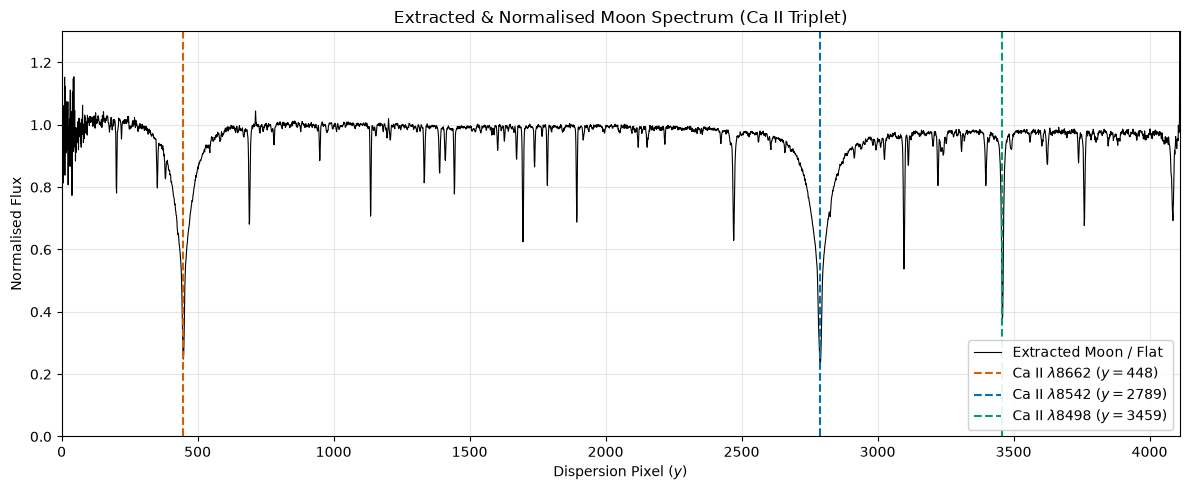

In [39]:
#Part 2 --- Extracting the Spectrum
#Note that I am assuming you've run the tramline detection code above.
from IPython.display import display, Markdown

#Load Moon data.
with fits.open('data/moon.fits') as hdul:
    moon = np.nan_to_num(hdul[0].data.astype(np.float64))

#Extract 1D spectra by summing across cross-dispersion between tramlines.
flat_1d = np.zeros(n_disp)
moon_1d = np.zeros(n_disp)

for y in range(n_disp):
    col_start = int(np.ceil(left_tramlines[y]))
    col_end = int(np.floor(right_tramlines[y]))
    
    col_start = max(0, col_start)
    col_end = min(n_xdisp - 1, col_end)
    
    flat_1d[y] = np.sum(flats[y, col_start : col_end + 1])
    moon_1d[y] = np.sum(moon[y, col_start : col_end + 1])

#Dividing Moon by Flat to normalise.
norm_spec = np.zeros_like(moon_1d)
valid_mask = flat_1d > 0
norm_spec[valid_mask] = moon_1d[valid_mask] / flat_1d[valid_mask]

#Rescale to 1.0 using upper 10th percentile to avoid outliers.
continuum_est = np.percentile(norm_spec[valid_mask], 90)
if continuum_est > 0:
    norm_spec /= continuum_est

#Inverting the spectrum so that absorption features are positive.
inv_spec = 1.0 - norm_spec
peaks, props = find_peaks(inv_spec, prominence=0.20, distance=250)

deepest_peak_idx = np.argsort(props['prominences'])[::-1][:3]
CaII_pix = np.sort(peaks[deepest_peak_idx])

gap_a = abs(CaII_pix[1] - CaII_pix[0])
gap_b = abs(CaII_pix[2] - CaII_pix[1])

if gap_a < gap_b:
    #y increases with wavelength
    lines_info = [
        (r'Ca II $\lambda 8498$', CaII_pix[0], 8498.02),
        (r'Ca II $\lambda 8542$', CaII_pix[1], 8542.09),
        (r'Ca II $\lambda 8662$', CaII_pix[2], 8662.14)
    ]
    direction_note = "Dispersion direction: Wavelength increases with row index y."
else:
    #y decreases with wavelength
    lines_info = [
        (r'Ca II $\lambda 8662$', CaII_pix[0], 8662.14),
        (r'Ca II $\lambda 8542$', CaII_pix[1], 8542.09),
        (r'Ca II $\lambda 8498$', CaII_pix[2], 8498.02)
    ]
    direction_note = "Dispersion direction: Wavelength decreases with row index y."

print(direction_note)
for name, pix, wavl in lines_info:
    display(Markdown(rf"* {name} $\rightarrow y = {pix}$ (Rest: ${wavl:.2f}\,\mathrm{{\AA}}$)"))

#Plot the normalised extracted spectrum.
plt.figure(figsize=(12, 5))
plt.plot(y_indices, norm_spec, color='black', lw=0.8, label='Extracted Moon / Flat')

colours = ['#D55E00', '#0072B2', '#009E73']
for (name, pix, _), col in zip(lines_info, colours):
    plt.axvline(pix, color=col, linestyle='--', lw=1.5, label=f'{name} ($y={pix}$)')

plt.title('Extracted & Normalised Moon Spectrum (Ca II Triplet)')
plt.xlabel('Dispersion Pixel ($y$)')
plt.ylabel('Normalised Flux')
plt.xlim(0, n_disp)
plt.ylim(0.0, 1.3)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('figures/Q4_extracted_spectrum.png', dpi=300)
plt.show()